# 250. Transferring ELM motif labels across species

ELM (the Eukaryotic Linear Motif resource) lists short motifs, most of them 3 to 15
residues, that a protein uses to bind a partner, get modified, get cut or be sent somewhere
in the cell. Each entry is one motif at one position in one protein, backed by experiments.
The question is whether a coarse alphabet can place such a motif from sequence alone.

The design has one problem to solve first. A hydrophobic-polar (HP) seed is 19 to 30
residues, and a motif is 3 to 15. An exact seed can only cover a motif by also matching the
8 to 20 flanking residues around it, and those flanks are mostly disordered. Whether that
can happen depends on whether the flanks keep their HP pattern in the ortholog. Stage 0
measures that on real ortholog pairs, with no search.

**Sources.**

| quantity | where it comes from |
|---|---|
| ELM instances and classes | `scripts/fetch_elm.py`: the ELM TSV exports, instances ELM marks "true positive" |
| usable instance | inside the QfO 2020_04 human sequence, and the class regex matches a stretch overlapping it (`scripts/elm_stage0_flanks.py`) |
| orthologs | 1:1 OMA pairs from the QfO release's `.idmapping` files, as `nextflow-runs/qfo-dnds-omega/bin/build_ortholog_pairs.py` pairs them. E. coli has no OMA cross-references in this release. |
| alignment | MAFFT 7.526 L-INS-i (`--localpair --maxiterate 1000`), one human-ortholog pair at a time |
| pLDDT over a motif | `bin/build_query_covariates.read_plddt` on the pipeline's human models for the midi-plus proteins, and on the AlphaFold cache for the rest when the model is as long as the sequence |
| disorder over the motif and its flanks | `bin/predict_disorder_metapredict.py`, metapredict 3.0.1, threshold 0.5 |
| Swiss-Prot features over a motif | `truth_swissprot/human_swissprot_truth.parquet` of the midi-plus run (midi-plus proteins only) |

**Three windows of the human protein.** *Motif*: the ELM instance's own residues.
*Flanks*: the 10 residues on each side (fewer at a protein end). *Rest*: every other
residue. Over each window, counting only alignment columns where both proteins have a
residue:

$$\Pr(\text{same class}) = \frac{\text{columns where human and ortholog residues are in the same hp\_pbotc\_1st\_ed2 class}}{\text{columns with a residue on both sides}}$$

with classes H = ACFILMPVWY and P = DEGHKNQRST, and percent identity the same with "same
residue" on top. The level expected by chance is

$$\Pr(\text{same class} \mid \text{chance}) = h_{\text{human}}\, h_{\text{ortholog}} + p_{\text{human}}\, p_{\text{ortholog}}$$

where $h_{\text{human}}$ and $p_{\text{human}}$ are the hydrophobic and polar shares of the
whole human protein, and $h_{\text{ortholog}}$, $p_{\text{ortholog}}$ the same for the
ortholog.

**Longest HP run covering the motif.** The longest run of consecutive alignment columns,
with no gap on either side, where every column has the same HP class on both proteins,
among runs that contain at least 80% of the motif's residues. An exact seed of length $k$
covering the motif can exist only if this run is at least $k$ long.

**Gate.** If fewer than 10% of instances have a run of 19 or more in chicken and every
species beyond it, exact 19-mers cannot carry this benchmark, and the mismatch-tolerant
extension arms have to.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

sys.path.insert(0, str(Path.cwd()))
import hero_example_utils as he

plt.rcParams.update({"figure.dpi": 110, "savefig.bbox": "tight", "font.size": 9.5})
pl.Config.set_tbl_rows(40)
pl.Config.set_tbl_cols(20)
pl.Config.set_tbl_width_chars(200)

FIG = Path("../figures")
TAB = Path("../tables")
S0 = Path("/Users/olga/data/elm-motif-transfer/stage0")
INST = pl.read_parquet(S0 / "stage0_instances.parquet")
PAIRS = pl.read_parquet(S0 / "stage0_pairs.parquet")
SPECIES = [
    "mouse",
    "chicken",
    "zebrafish",
    "ciona",
    "fly",
    "worm",
    "yeast",
    "arabidopsis",
    "ecoli",
]
GROUP = {
    "mouse": "mouse (100 Mya)",
    "chicken": "chicken, zebrafish (300-430 Mya)",
    "zebrafish": "chicken, zebrafish (300-430 Mya)",
    "ciona": "ciona, fly, worm (550-650 Mya)",
    "fly": "ciona, fly, worm (550-650 Mya)",
    "worm": "ciona, fly, worm (550-650 Mya)",
    "yeast": "yeast, arabidopsis (900-1500 Mya)",
    "arabidopsis": "yeast, arabidopsis (900-1500 Mya)",
}
GROUPS = list(dict.fromkeys(GROUP.values()))
PAIRS = PAIRS.with_columns(group=pl.col("species").replace_strict(GROUP, default=None))
BINS = ["3-6 aa", "7-10 aa", "11-15 aa", "16+ aa"]


def counts(df, label):
    return (
        df.group_by("length_bin")
        .agg(instances=pl.len(), proteins=pl.col("accession").n_unique())
        .with_columns(set=pl.lit(label))
    )


tab = pl.concat(
    [
        counts(INST, "all human proteins"),
        counts(INST.filter("in_midi_plus"), "midi-plus proteins"),
    ]
)
print(
    f"usable human ELM instances: {INST.height:_} on {INST['accession'].n_unique():_} proteins, "
    f"{INST['elm_class'].n_unique()} classes; on the 998 midi-plus proteins: "
    f"{INST.filter('in_midi_plus').height} on {INST.filter('in_midi_plus')['accession'].n_unique()} proteins"
)
print(
    tab.pivot(on="set", index="length_bin", values="instances").sort(
        pl.col("length_bin").replace_strict({b: i for i, b in enumerate(BINS)})
    )
)
print(
    f"PubMed IDs listed by ELM: {INST['pmids'].str.split(' ').list.len().sum():_} "
    f"over {INST.height:_} instances"
)

usable human ELM instances: 2_160 on 1_303 proteins, 282 classes; on the 998 midi-plus proteins: 100 on 67 proteins
shape: (4, 3)
┌────────────┬────────────────────┬────────────────────┐
│ length_bin ┆ all human proteins ┆ midi-plus proteins │
│ ---        ┆ ---                ┆ ---                │
│ str        ┆ u32                ┆ u32                │
╞════════════╪════════════════════╪════════════════════╡
│ 3-6 aa     ┆ 1059               ┆ 54                 │
│ 7-10 aa    ┆ 864                ┆ 31                 │
│ 11-15 aa   ┆ 150                ┆ 7                  │
│ 16+ aa     ┆ 87                 ┆ 8                  │
└────────────┴────────────────────┴────────────────────┘
PubMed IDs listed by ELM: 2_734 over 2_160 instances


Per-motif covariates by motif length (disorder = share of residues metapredict calls disordered):
shape: (4, 8)
┌────────────┬──────┬──────────────┬────────────────────┬──────────────────────┬───────────────────────┬────────────────────────┬────────────────────────────────┐
│ length_bin ┆ n    ┆ n_with_plddt ┆ median_plddt_motif ┆ share_plddt_below_50 ┆ median_disorder_motif ┆ median_disorder_flanks ┆ share_flanks_mostly_disordered │
│ ---        ┆ ---  ┆ ---          ┆ ---                ┆ ---                  ┆ ---                   ┆ ---                    ┆ ---                            │
│ str        ┆ u32  ┆ u32          ┆ f64                ┆ f64                  ┆ f64                   ┆ f64                    ┆ f64                            │
╞════════════╪══════╪══════════════╪════════════════════╪══════════════════════╪═══════════════════════╪════════════════════════╪════════════════════════════════╡
│ 3-6 aa     ┆ 1059 ┆ 1009         ┆ 44.355             ┆ 0.602577       

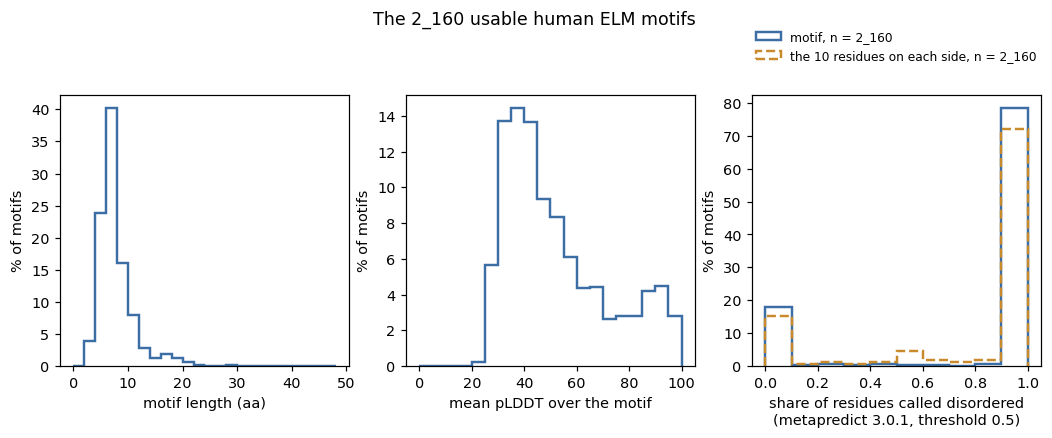

In [2]:
cov = (
    INST.group_by("length_bin")
    .agg(
        n=pl.len(),
        n_with_plddt=pl.col("mean_plddt_motif").is_not_null().sum(),
        median_plddt_motif=pl.col("mean_plddt_motif").median(),
        share_plddt_below_50=(pl.col("mean_plddt_motif") < 50).mean(),
        median_disorder_motif=pl.col("frac_disordered_motif").median(),
        median_disorder_flanks=pl.col("frac_disordered_flanks").median(),
        share_flanks_mostly_disordered=(pl.col("frac_disordered_flanks") >= 0.5).mean(),
    )
    .sort(pl.col("length_bin").replace_strict({b: i for i, b in enumerate(BINS)}))
)
print(
    "Per-motif covariates by motif length (disorder = share of residues metapredict calls disordered):"
)
print(cov)
mp = INST.filter("in_midi_plus").explode("swissprot_features")
print("\nSwiss-Prot feature types overlapping a motif, midi-plus proteins only:")
print(mp.group_by("swissprot_features").len().sort("len", descending=True))

fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.2))
for ax, col, lab, bins in [
    (axes[0], "motif_length", "motif length (aa)", np.arange(0, 50, 2)),
    (axes[1], "mean_plddt_motif", "mean pLDDT over the motif", np.arange(0, 102, 5)),
    (
        axes[2],
        None,
        "share of residues called disordered\n(metapredict 3.0.1, threshold 0.5)",
        np.linspace(0, 1, 11),
    ),
]:
    if col:
        v = INST[col].drop_nulls().to_numpy()
        ax.hist(
            v,
            bins=bins,
            histtype="step",
            lw=1.6,
            color="#3B6EA5",
            weights=np.full(v.size, 100 / v.size),
        )
    else:
        for c, ls, lab2 in (
            ("frac_disordered_motif", "-", "motif"),
            ("frac_disordered_flanks", "--", "the 10 residues on each side"),
        ):
            v = INST[c].drop_nulls().to_numpy()
            ax.hist(
                v,
                bins=bins,
                histtype="step",
                lw=1.6,
                ls=ls,
                color="#3B6EA5" if ls == "-" else "#C98A2B",
                weights=np.full(v.size, 100 / v.size),
                label=f"{lab2}, n = {v.size:_}",
            )
        ax.legend(
            loc="upper center", bbox_to_anchor=(0.5, 1.28), frameon=False, fontsize=8
        )
    ax.set_xlabel(lab)
    ax.set_ylabel("% of motifs")
fig.suptitle(f"The {INST.height:_} usable human ELM motifs", y=1.12)
fig.savefig(FIG / "250_stage0_motif_covariates.png", dpi=200)

## Stage 0. Do the flanks keep their HP pattern?

Human ELM instances with a 1:1 OMA ortholog, per species:
shape: (9, 6)
┌─────────────┬─────────────────────────────────┬───────────┬──────────┬─────────────────────┬──────────────────────┐
│ species     ┆ group                           ┆ instances ┆ proteins ┆ midi_plus_instances ┆ median_rest_identity │
│ ---         ┆ ---                             ┆ ---       ┆ ---      ┆ ---                 ┆ ---                  │
│ str         ┆ str                             ┆ u32       ┆ u32      ┆ u32                 ┆ f64                  │
╞═════════════╪═════════════════════════════════╪═══════════╪══════════╪═════════════════════╪══════════════════════╡
│ mouse       ┆ mouse (100 Mya)                 ┆ 1347      ┆ 818      ┆ 64                  ┆ 0.90507              │
│ chicken     ┆ chicken, zebrafish (300-430 My… ┆ 550       ┆ 337      ┆ 25                  ┆ 0.780017             │
│ zebrafish   ┆ chicken, zebrafish (300-430 My… ┆ 855       ┆ 517      ┆ 33                  ┆ 0.63764

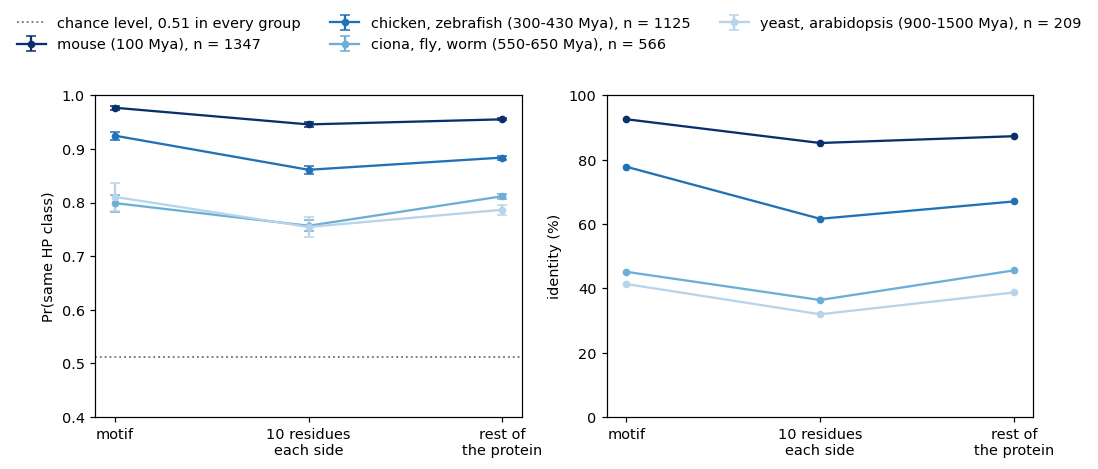

In [3]:
per_sp = (
    PAIRS.group_by("species")
    .agg(
        instances=pl.len(),
        proteins=pl.col("accession").n_unique(),
        midi_plus_instances=pl.col("in_midi_plus").sum(),
        median_rest_identity=pl.col("rest_identity").median(),
    )
    .join(pl.DataFrame({"species": SPECIES}), on="species", how="right")
    .fill_null(0)
    .with_columns(
        pl.col("species").replace_strict(GROUP, default="no OMA pairs").alias("group")
    )
)
print("Human ELM instances with a 1:1 OMA ortholog, per species:")
print(
    per_sp.select(
        "species",
        "group",
        "instances",
        "proteins",
        "midi_plus_instances",
        "median_rest_identity",
    )
)

rng = np.random.default_rng(250)


def boot_mean(v, n=1000):
    v = np.asarray(v, float)
    v = v[~np.isnan(v)]
    if v.size == 0:
        return np.nan, np.nan, np.nan
    b = rng.choice(v, (n, v.size)).mean(1)
    return v.mean(), *np.percentile(b, [2.5, 97.5])


WINDOWS = [
    ("motif", "motif"),
    ("flanks", "10 residues\neach side"),
    ("rest", "rest of\nthe protein"),
]
rows = []
for g in GROUPS:
    sub = PAIRS.filter(pl.col("group") == g)
    # One value per human instance: the mean over its orthologs in the group, so the interval
    # resamples instances, not instance-species pairs.
    per_inst = (
        sub.group_by("elm_instance")
        .agg(
            *[pl.col(f"{w}_pr_same_class").mean() for w, _ in WINDOWS],
            *[pl.col(f"{w}_identity").mean() for w, _ in WINDOWS],
            pl.col("pr_same_class_chance").mean(),
        )
        .sort("elm_instance")
    )  # fixed order: group_by's is arbitrary
    for w, _ in WINDOWS:
        m, lo, hi = boot_mean(per_inst[f"{w}_pr_same_class"].to_numpy())
        mi, _, _ = boot_mean(per_inst[f"{w}_identity"].to_numpy())
        rows.append(
            {
                "group": g,
                "window": w,
                "n_instances": per_inst.height,
                "pr_same_class": m,
                "ci_low": lo,
                "ci_high": hi,
                "identity": mi,
                "pr_same_class_chance": per_inst["pr_same_class_chance"].mean(),
            }
        )
W = pl.DataFrame(rows)
print(
    "\nPr(same hp_pbotc_1st_ed2 class) and percent identity by window, mean over instances, "
    "95% bootstrap interval by instance:"
)
print(W.with_columns(pl.col(pl.Float64).round(3)))
W.write_csv(TAB / "250_stage0_windows.csv")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.8))
# One blue ramp, darkest = closest to human: the groups are ordered by distance.
COL = dict(zip(GROUPS, ["#08306B", "#2171B5", "#6BAED6", "#B7D4EA"]))
chance = W["pr_same_class_chance"]
a1.axhline(
    chance.mean(),
    color="0.45",
    ls=":",
    lw=1.2,
    zorder=0,
    label=(
        f"chance level, {chance.min():.2f} in every group"
        if f"{chance.min():.2f}" == f"{chance.max():.2f}"
        else f"chance level, {chance.min():.2f}-{chance.max():.2f}"
    ),
)
x = np.arange(len(WINDOWS))
for g in GROUPS:
    s = W.filter(pl.col("group") == g)
    if s.is_empty():
        continue
    a1.errorbar(
        x,
        s["pr_same_class"],
        yerr=[s["pr_same_class"] - s["ci_low"], s["ci_high"] - s["pr_same_class"]],
        marker="o",
        ms=4,
        capsize=3,
        color=COL[g],
        label=f"{g}, n = {s['n_instances'][0]}",
    )
    a2.plot(x, 100 * s["identity"], marker="o", ms=4, color=COL[g])
for a, lab in ((a1, "Pr(same HP class)"), (a2, "identity (%)")):
    a.set_xticks(x, [l for _, l in WINDOWS])
    a.set_ylabel(lab)
a1.set_ylim(0.4, 1.0)
a2.set_ylim(0, 100)
fig.legend(
    *a1.get_legend_handles_labels(),
    loc="upper center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, 1.1),
)
fig.savefig(FIG / "250_stage0_flank_conservation.png", dpi=200)

Longest run of identical HP classes covering >= 80% of the motif, per species:
shape: (9, 6)
┌─────────────┬──────┬─────────────┬─────────────────┬─────────────────┬────────────┐
│ species     ┆ mya  ┆ n_instances ┆ share_run_ge_10 ┆ share_run_ge_19 ┆ median_run │
│ ---         ┆ ---  ┆ ---         ┆ ---             ┆ ---             ┆ ---        │
│ str         ┆ i64  ┆ u32         ┆ f64             ┆ f64             ┆ f64        │
╞═════════════╪══════╪═════════════╪═════════════════╪═════════════════╪════════════╡
│ mouse       ┆ 100  ┆ 1347        ┆ 0.866           ┆ 0.738           ┆ 40.0       │
│ chicken     ┆ 300  ┆ 550         ┆ 0.669           ┆ 0.498           ┆ 18.0       │
│ zebrafish   ┆ 430  ┆ 855         ┆ 0.522           ┆ 0.274           ┆ 10.0       │
│ ciona       ┆ 550  ┆ 325         ┆ 0.151           ┆ 0.04            ┆ 0.0        │
│ fly         ┆ 600  ┆ 284         ┆ 0.148           ┆ 0.056           ┆ 0.0        │
│ worm        ┆ 650  ┆ 251         ┆ 0.08      

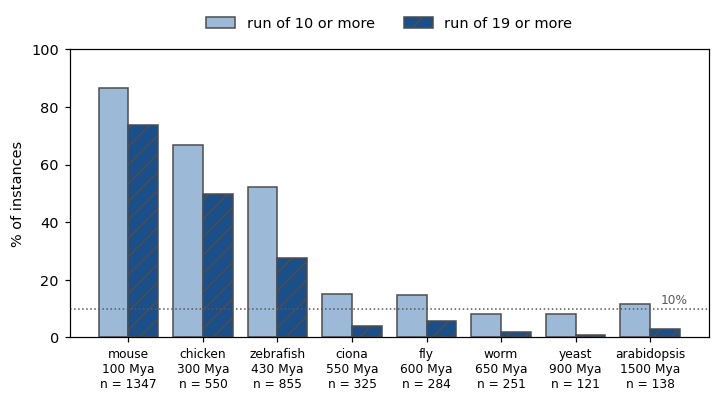

In [4]:
runs = (
    PAIRS.group_by("species")
    .agg(
        n_instances=pl.len(),
        share_run_ge_19=(pl.col("longest_hp_run_covering_motif") >= 19).mean(),
        share_run_ge_10=(pl.col("longest_hp_run_covering_motif") >= 10).mean(),
        median_run=pl.col("longest_hp_run_covering_motif").median(),
    )
    .join(pl.DataFrame({"species": SPECIES}), on="species", how="right")
    .with_columns(
        mya=pl.col("species").replace_strict(
            dict(zip(SPECIES, [100, 300, 430, 550, 600, 650, 900, 1500, 2000]))
        )
    )
)
print("Longest run of identical HP classes covering >= 80% of the motif, per species:")
print(
    runs.select(
        "species",
        "mya",
        "n_instances",
        "share_run_ge_10",
        "share_run_ge_19",
        "median_run",
    ).with_columns(pl.col(pl.Float64).round(3))
)
runs.write_csv(TAB / "250_stage0_longest_hp_run.csv")
by_bin = (
    PAIRS.filter(pl.col("mya") >= 300)
    .group_by("length_bin")
    .agg(
        n=pl.len(),
        share_run_ge_19=(pl.col("longest_hp_run_covering_motif") >= 19).mean(),
        share_run_ge_10=(pl.col("longest_hp_run_covering_motif") >= 10).mean(),
    )
    .sort(pl.col("length_bin").replace_strict({b: i for i, b in enumerate(BINS)}))
)
print("\nChicken and beyond, by motif length:")
print(by_bin.with_columns(pl.col(pl.Float64).round(3)))

fig, ax = plt.subplots(figsize=(7.5, 3.4))
r = runs.filter(pl.col("n_instances").is_not_null() & (pl.col("n_instances") > 0))
xs = np.arange(r.height)
ax.bar(
    xs - 0.2,
    100 * r["share_run_ge_10"],
    width=0.4,
    color="#9DB9D8",
    edgecolor="0.3",
    label="run of 10 or more",
)
ax.bar(
    xs + 0.2,
    100 * r["share_run_ge_19"],
    width=0.4,
    color="#1B4F8A",
    edgecolor="0.3",
    hatch="//",
    label="run of 19 or more",
)
ax.axhline(10, color="0.35", ls=":", lw=1)
ax.text(r.height - 0.5, 10.5, "10%", ha="right", va="bottom", fontsize=8, color="0.35")
ax.set_xticks(
    xs,
    [
        f"{s}\n{m} Mya\nn = {n}"
        for s, m, n in zip(r["species"], r["mya"], r["n_instances"])
    ],
    fontsize=8,
)
ax.set_ylabel("% of instances")
ax.set_ylim(0, 100)
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=2, frameon=False)
fig.savefig(FIG / "250_stage0_longest_hp_run.png", dpi=200)

In [5]:
# Verdict, computed, species by species from chicken outward (300 Mya and beyond).
far = runs.filter((pl.col("mya") >= 300) & (pl.col("n_instances") > 0)).sort("mya")
under = far.filter(pl.col("share_run_ge_19") < 0.10)
over = far.filter(pl.col("share_run_ge_19") >= 0.10)
print(
    "Share of instances with an identical-HP-class run of 19 or more covering the motif:"
)
for r in far.iter_rows(named=True):
    print(
        f"  {r['species']:12s} {r['mya']:>5} Mya  {100 * r['share_run_ge_19']:5.1f}%  "
        f"(run of 10 or more: {100 * r['share_run_ge_10']:5.1f}%, n = {r['n_instances']})"
    )
if over.is_empty():
    print(
        "VERDICT: under 10% in chicken and every species beyond it. Exact 19-mers cannot carry this "
        "benchmark; the extension arms are load-bearing."
    )
else:
    print(
        f"VERDICT: the gate as written (under 10% in chicken AND every species beyond) is not met: "
        f"{', '.join(over['species'])} are at or above 10%. It is met from "
        f"{under['species'][0] if under.height else 'no species'} outward "
        f"({', '.join(under['species'])}): there, exact 19-mers cannot carry the benchmark and the "
        f"extension arms are load-bearing."
    )

Share of instances with an identical-HP-class run of 19 or more covering the motif:
  chicken        300 Mya   49.8%  (run of 10 or more:  66.9%, n = 550)
  zebrafish      430 Mya   27.4%  (run of 10 or more:  52.2%, n = 855)
  ciona          550 Mya    4.0%  (run of 10 or more:  15.1%, n = 325)
  fly            600 Mya    5.6%  (run of 10 or more:  14.8%, n = 284)
  worm           650 Mya    2.0%  (run of 10 or more:   8.0%, n = 251)
  yeast          900 Mya    0.8%  (run of 10 or more:   8.3%, n = 121)
  arabidopsis   1500 Mya    2.9%  (run of 10 or more:  11.6%, n = 138)
VERDICT: the gate as written (under 10% in chicken AND every species beyond) is not met: chicken, zebrafish are at or above 10%. It is met from ciona outward (ciona, fly, worm, yeast, arabidopsis): there, exact 19-mers cannot carry the benchmark and the extension arms are load-bearing.


In [6]:
# The residues behind the numbers: one instance per species group, the one whose longest
# covering HP run is the group median. Motif +- 10, human above ortholog, then the classes.
def show(r):
    aln = (
        (S0 / "alignments" / r["species"] / f"{r['accession']}__{r['ortholog']}.fasta")
        .read_text()
        .split(">")[1:]
    )
    ha, ta = ["".join(x.splitlines()[1:]).upper() for x in aln]
    pos = []
    i = 0
    for c in ha:
        pos.append(None if c == "-" else i)
        i += c != "-"
    s, e = r["start"], r["end"]
    cols = [k for k, p in enumerate(pos) if p is not None and s - 10 <= p < e + 10]
    c0, c1 = cols[0], cols[-1] + 1
    hs, ts = ha[c0:c1], ta[c0:c1]
    ident = sum(a == b and a != "-" for a, b in zip(hs, ts))
    cls = lambda x: "-" if x == "-" else he.class_string(x)
    hc, tc = "".join(cls(a) for a in hs), "".join(cls(b) for b in ts)
    motif = "".join(
        "*" if pos[k] is not None and s <= pos[k] < e else " " for k in range(c0, c1)
    )
    run = [(a == b and a != "-") for a, b in zip(hc, tc)]
    best, cur, bs, st = 0, 0, 0, 0
    for k, ok in enumerate(run):
        cur, st = (cur + 1, st) if ok else (0, k + 1)
        if cur > best:
            best, bs = cur, st
    seed = "".join("^" if bs <= k < bs + best else " " for k in range(len(run)))
    lab = 40
    print(
        f"--- {r['elm_class']}, human {r['accession']} motif {s + 1}-{e} ({e - s} aa), {r['species']} "
        f"{r['ortholog']}; {ident} of {len(hs)} alignment columns identical over motif +-10; "
        f"longest covering HP run in the whole alignment: {r['longest_hp_run_covering_motif']}"
    )
    print(f"{'motif':<{lab}}{motif}")
    print(f"{'human ' + r['accession']:<{lab}}{hs}")
    print(
        f"{'':<{lab}}{''.join('|' if a == b and a != '-' else ' ' for a, b in zip(hs, ts))}"
    )
    print(f"{r['species'] + ' ' + r['ortholog']:<{lab}}{ts}")
    print(f"{'hp_pbotc_1st_ed2':<{lab}}{hc}")
    print(f"{'':<{lab}}{''.join('|' if x else ' ' for x in run)}")
    print(f"{'':<{lab}}{tc}")
    print(f"{'longest same-class run in this window':<{lab}}{seed}\n")


J = PAIRS.join(INST.select("elm_instance", "start", "end"), on="elm_instance")
for g in GROUPS:
    sub = J.filter(pl.col("group") == g).sort(
        "longest_hp_run_covering_motif", "elm_instance"
    )
    if sub.height:
        show(sub.row(sub.height // 2, named=True))

--- DOC_ANK_TNKS_1, human Q9NWV8 motif 27-34 (8 aa), mouse Q3UI43; 23 of 32 alignment columns identical over motif +-10; longest covering HP run in the whole alignment: 40
motif                                                 ********          
human Q9NWV8                            EEHS----AEPRPRTRSNPEGAEDRAVGAQAS
                                        ||       |||| |||||||||||| |||||
mouse Q3UI43                            EEEGEETISEPRPHTRSNPEGAEDRALGAQAS
hp_pbotc_1st_ed2                        PPPP----HPHPHPPPPPHPPHPPPHHPHPHP
                                        ||||     |||||||||||||||||||||||
                                        PPPPPPPHPPHPHPPPPPHPPHPPPHHPHPHP
longest same-class run in this window            ^^^^^^^^^^^^^^^^^^^^^^^

--- TRG_ER_FFAT_2, human O95772 motif 205-214 (10 aa), chicken A0A1L1RKF5; 25 of 32 alignment columns identical over motif +-10; longest covering HP run in the whole alignment: 12
motif                                              **********  

## Step 4. Target-side labels: how many cases can "transfer" be scored on?

Transfer (did a tool copy the right motif label from the target) needs a label on the target
protein. `scripts/elm_tiers.py` projects each human motif onto its 1:1 OMA ortholog through
the MAFFT alignment and looks for three kinds of label there, each in its own table:

- `tier_experimental`: the ortholog carries its own ELM "true positive" instance of the same
  class, overlapping the projected position.
- `tier_swissprot`: the ortholog has a Swiss-Prot MOTIF or REGION feature overlapping the
  projected position (UniProtKB/Swiss-Prot flat file on disk, see the provenance file).
- `tier_regex_projected`: the class regex matches the ortholog there. Quarantined: used only
  for the cover check, never as a headline, because the regex is a competitor.

`regex_matches_target` is computed once per pair, in its own step (`regex_on_target`), and
read in exactly two places: as the truth of `tier_regex_projected`, and as the filter that
selects the "regex fails" stratum (correction C1).

Human ELM instances with a target-side label at the aligned position, per species:
shape: (8, 5)
┌─────────────┬──────────────────┬────────────────────────┬───────┬────────────────────────────┐
│ species     ┆ elm_experimental ┆ swissprot_experimental ┆ pairs ┆ share_regex_matches_target │
│ ---         ┆ ---              ┆ ---                    ┆ ---   ┆ ---                        │
│ str         ┆ u32              ┆ u32                    ┆ u32   ┆ f64                        │
╞═════════════╪══════════════════╪════════════════════════╪═══════╪════════════════════════════╡
│ mouse       ┆ 64               ┆ 48                     ┆ 1347  ┆ 0.93                       │
│ chicken     ┆ 6                ┆ 0                      ┆ 550   ┆ 0.847                      │
│ zebrafish   ┆ 0                ┆ 0                      ┆ 855   ┆ 0.77                       │
│ ciona       ┆ 0                ┆ 0                      ┆ 325   ┆ 0.422                      │
│ fly         ┆ 6             

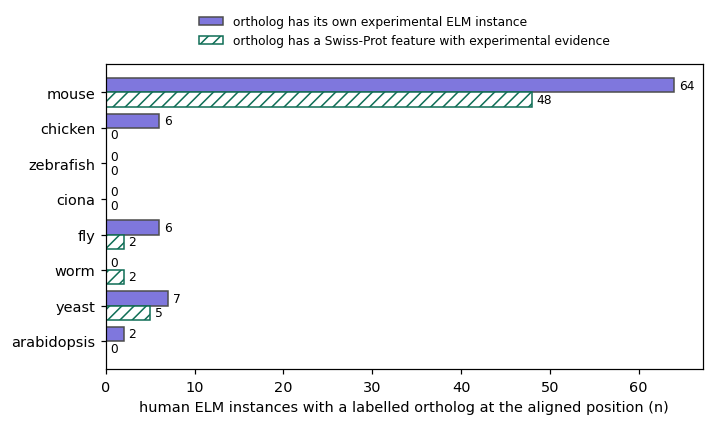

In [7]:
T = Path("/Users/olga/data/elm-motif-transfer/tiers")
EXP = pl.read_parquet(T / "tier_experimental.parquet")
SPR = pl.read_parquet(T / "tier_swissprot.parquet").with_columns(
    experimental_evidence=pl.col("sp_evidence").str.contains("ECO:0000269"),
    disordered_note=pl.col("sp_note").str.contains("(?i)^disordered"),
)
ROT = pl.read_parquet(T / "regex_on_target.parquet")
C1 = pl.read_parquet(T / "regex_fails_stratum.parquet")
order = {s: i for i, s in enumerate(SPECIES)}

exp_at = EXP.filter("overlaps_projection")
spr_exp = SPR.filter(pl.col("experimental_evidence") & ~pl.col("disordered_note"))
truth = (
    pl.DataFrame({"species": SPECIES[:-1]})
    .join(
        exp_at.group_by("species").agg(
            elm_experimental=pl.col("elm_instance").n_unique()
        ),
        on="species",
        how="left",
    )
    .join(
        spr_exp.group_by("species").agg(
            swissprot_experimental=pl.col("elm_instance").n_unique()
        ),
        on="species",
        how="left",
    )
    .join(
        ROT.group_by("species").agg(
            pairs=pl.len(),
            share_regex_matches_target=pl.col("regex_matches_target").mean(),
        ),
        on="species",
        how="left",
    )
    .fill_null(0)
)
print(
    "Human ELM instances with a target-side label at the aligned position, per species:"
)
print(truth.with_columns(pl.col("share_regex_matches_target").round(3)))
truth.write_csv(TAB / "250_step4_truth_by_species.csv")
print(
    f"\ntier_experimental at the aligned position: {exp_at.height} rows, "
    f"{exp_at['elm_instance'].n_unique()} human instances; beyond mouse: "
    f"{exp_at.filter(pl.col('species') != 'mouse')['elm_instance'].n_unique()}"
)
print("\ntier_swissprot features at the aligned position, by kind:")
print(
    SPR.group_by("sp_type", "disordered_note", "experimental_evidence")
    .len()
    .sort("sp_type", "disordered_note", "experimental_evidence")
)
print(
    f"\nC1 regex-fails stratum (experimental label present, regex does not match the ortholog): "
    f"{C1.height} rows"
)
print(
    f"Swiss-Prot experimental features where regex_matches_target is false: "
    f"{spr_exp.join(ROT.select('elm_instance', 'species', 'regex_matches_target'), on=['elm_instance', 'species']).filter(~pl.col('regex_matches_target')).height} rows"
)
n_exp = exp_at["elm_instance"].n_unique()
print(
    f"\nC3 regime: n(tier_experimental) = {n_exp}; "
    + (
        "under 50, so tier_swissprot is primary"
        if n_exp < 50
        else f"50 or more overall, but {exp_at.filter(pl.col('species') == 'mouse')['elm_instance'].n_unique()} are mouse"
    )
)

fig, ax = plt.subplots(figsize=(7, 3.6))
y = np.arange(truth.height)
ax.barh(
    y - 0.2,
    truth["elm_experimental"],
    height=0.4,
    color="#7F77DD",
    edgecolor="0.3",
    label="ortholog has its own experimental ELM instance",
)
ax.barh(
    y + 0.2,
    truth["swissprot_experimental"],
    height=0.4,
    color="white",
    edgecolor="#0F6E56",
    hatch="///",
    label="ortholog has a Swiss-Prot feature with experimental evidence",
)
for yi, a, b in zip(y, truth["elm_experimental"], truth["swissprot_experimental"]):
    ax.annotate(
        str(a),
        (a, yi - 0.2),
        xytext=(3, 0),
        textcoords="offset points",
        va="center",
        fontsize=8,
    )
    ax.annotate(
        str(b),
        (b, yi + 0.2),
        xytext=(3, 0),
        textcoords="offset points",
        va="center",
        fontsize=8,
    )
ax.set_yticks(y, truth["species"])
ax.invert_yaxis()
ax.set_xlabel(
    "human ELM instances with a labelled ortholog at the aligned position (n)"
)
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.02), frameon=False, fontsize=8)
fig.savefig(FIG / "250_step4_truth_by_species.png", dpi=200)

## Mismatch penalty: does the Pfam kappa hold on these pairs?

The extension's mismatch penalty C per alphabet comes from kappa, the chance-corrected class
agreement, measured on Pfam-A 38.2 seed pairs at 20-30% identity (`assets/
kappa_by_alphabet.pfam_a_38.2_seed_pairs_20-30pct_identity.tsv`, notebook 230).
`scripts/elm_kappa.py` measures kappa on the ELM ortholog pairs with notebook 230's own
function (`hp_conservation_utils.pair_stats`), for the motif, the 10 residues each side, and
the rest of the protein. The motif and flanks are pooled over all pairs of a species (6 and
20 columns per pair are too few for a per-pair value); the rest of the protein is also given
as notebook 230's per-pair mean over pairs with at least 50 columns. C = -ln(1 - kappa) /
ln(1 + kappa x classes - kappa).

hp_pbotc_1st_ed2 on the ELM ortholog pairs (Pfam 20-30% identity: kappa 0.4389, C 1.59):
shape: (24, 8)
┌─────────────┬──────┬────────┬─────────┬──────────────┬──────────┬─────────────────────┬─────────────────┐
│ species     ┆ mya  ┆ window ┆ n_pairs ┆ kappa_pooled ┆ C_pooled ┆ kappa_per_pair_mean ┆ C_per_pair_mean │
│ ---         ┆ ---  ┆ ---    ┆ ---     ┆ ---          ┆ ---      ┆ ---                 ┆ ---             │
│ str         ┆ i64  ┆ str    ┆ i64     ┆ f64          ┆ f64      ┆ f64                 ┆ f64             │
╞═════════════╪══════╪════════╪═════════╪══════════════╪══════════╪═════════════════════╪═════════════════╡
│ mouse       ┆ 100  ┆ flanks ┆ 1347    ┆ 0.887        ┆ 3.438    ┆ null                ┆ null            │
│ mouse       ┆ 100  ┆ motif  ┆ 1347    ┆ 0.955        ┆ 4.622    ┆ null                ┆ null            │
│ mouse       ┆ 100  ┆ rest   ┆ 1347    ┆ 0.906        ┆ 3.673    ┆ 0.908               ┆ 3.691           │
│ chicken     ┆ 300  ┆ flanks ┆ 

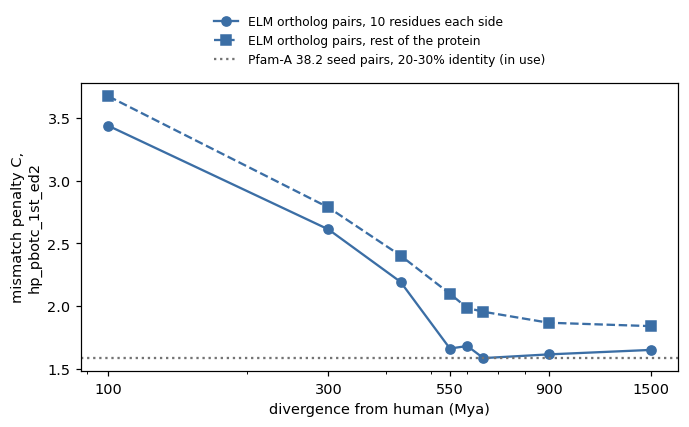

In [8]:
K = pl.read_csv(TAB / "250_elm_kappa_by_species.csv")
PF = pl.read_csv(
    Path(
        "../nextflow-runs/qfo-pfam-region-benchmark/assets/kappa_by_alphabet.pfam_a_38.2_seed_pairs_20-30pct_identity.tsv"
    ),
    separator="\t",
    comment_prefix="#",
).select(
    "alphabet", pl.col("kappa").alias("kappa_pfam"), pl.col("c_opt").alias("C_pfam")
)
k_hp = (
    K.filter(pl.col("alphabet") == "hp_pbotc_1st_ed2")
    .select(
        "species",
        "mya",
        "window",
        "n_pairs",
        "kappa_pooled",
        "C_pooled",
        "kappa_per_pair_mean",
        "C_per_pair_mean",
    )
    .sort("mya", "window")
)
print(
    "hp_pbotc_1st_ed2 on the ELM ortholog pairs (Pfam 20-30% identity: kappa 0.4389, C 1.59):"
)
print(k_hp.with_columns(pl.col(pl.Float64).round(3)))
far = (
    K.filter((pl.col("mya") >= 550) & (pl.col("window") == "flanks"))
    .group_by("alphabet")
    .agg(
        kappa_flanks_550plus=pl.col("kappa_pooled").mean(),
        C_flanks_550plus=pl.col("C_pooled").mean(),
    )
    .join(PF, on="alphabet", how="left")
    .sort("alphabet")
)
print(
    "\nEvery alphabet: flanks, mean over species at 550 Mya or more, against the Pfam value:"
)
print(far.with_columns(pl.col(pl.Float64).round(3)))

fig, ax = plt.subplots(figsize=(7, 3.4))
for w, ls, mk in (("flanks", "-", "o"), ("rest", "--", "s")):
    s = k_hp.filter(pl.col("window") == w)
    ax.plot(
        s["mya"],
        s["C_pooled"],
        ls=ls,
        marker=mk,
        color="#3B6EA5",
        label=f"ELM ortholog pairs, {'10 residues each side' if w == 'flanks' else 'rest of the protein'}",
    )
ax.axhline(
    1.59, color="0.45", ls=":", label="Pfam-A 38.2 seed pairs, 20-30% identity (in use)"
)
ax.set_xscale("log")
ax.set_xticks([100, 300, 550, 900, 1500], ["100", "300", "550", "900", "1500"])
ax.set_xlabel("divergence from human (Mya)")
ax.set_ylabel("mismatch penalty C,\nhp_pbotc_1st_ed2")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.02), frameon=False, fontsize=8)
fig.savefig(FIG / "250_kappa_penalty_by_species.png", dpi=200)

## Seed lengths: two per alphabet, within memory

`scripts/elm_seed_floor.py` counts, with `kmerseek index --stats-only` on the QfO human
proteome, how many human proteins contain a seed taken at a random position. `k_main` is the
shortest k under 100 proteins; `k_small` the shortest under 1_000, raised until it fits the
128 GB search memory limit as measured on the same nine proteomes in the midi-plus trace.

memory: load cap 452.4 (largest load whose worst midi-plus search stayed under 128 GB)
shape: (19, 6)
┌──────────────────────────┬────────┬──────────────────────────┬─────────┬─────────────────────┬─────────────────────────────────┐
│ alphabet                 ┆ k_main ┆ proteins_per_seed_k_main ┆ k_small ┆ k_small_fits_memory ┆ proteins_per_seed_k_small_fits… │
│ ---                      ┆ ---    ┆ ---                      ┆ ---     ┆ ---                 ┆ ---                             │
│ str                      ┆ i64    ┆ f64                      ┆ i64     ┆ i64                 ┆ f64                             │
╞══════════════════════════╪════════╪══════════════════════════╪═════════╪═════════════════════╪═════════════════════════════════╡
│ protein20                ┆ 5      ┆ 13.5                     ┆ 4       ┆ null                ┆ null                            │
│ uniprot18                ┆ 5      ┆ 33.2                     ┆ 4       ┆ null                ┆ null           

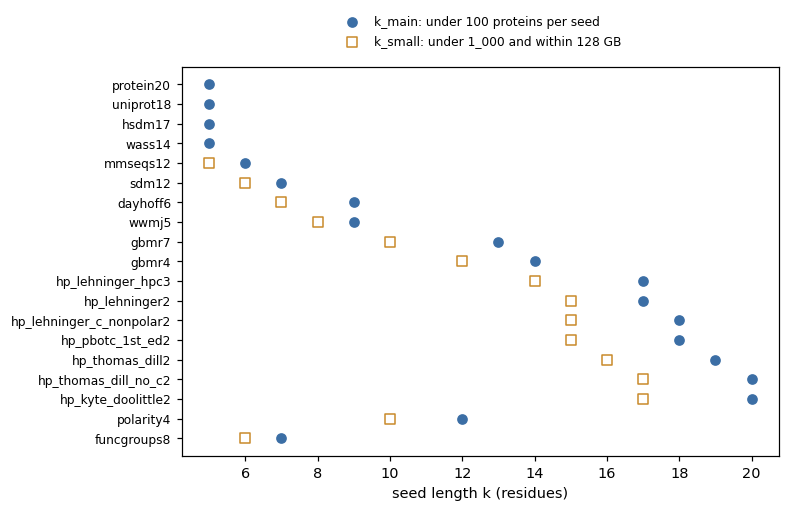

In [9]:
TK = pl.read_csv(TAB / "250_two_k_per_alphabet.csv")
print(
    f"memory: load cap {TK['load_cap'][0]} (largest load whose worst midi-plus search stayed under 128 GB)"
)
print(
    TK.select(
        "alphabet",
        "k_main",
        "proteins_per_seed_k_main",
        "k_small",
        "k_small_fits_memory",
        "proteins_per_seed_k_small_fits_memory",
    )
)
fig, ax = plt.subplots(figsize=(7, 4.6))
y = np.arange(TK.height)
ax.scatter(
    TK["k_main"],
    y,
    marker="o",
    color="#3B6EA5",
    label="k_main: under 100 proteins per seed",
    zorder=3,
)
ks = TK["k_small_fits_memory"].to_list()
ax.scatter(
    [k for k in ks if k is not None],
    [yi for yi, k in zip(y, ks) if k is not None],
    marker="s",
    facecolor="white",
    edgecolor="#C98A2B",
    label="k_small: under 1_000 and within 128 GB",
    zorder=3,
)
ax.set_yticks(y, TK["alphabet"], fontsize=8)
ax.invert_yaxis()
ax.set_xlabel("seed length k (residues)")
ax.legend(
    loc="lower center", bbox_to_anchor=(0.5, 1.02), frameon=False, fontsize=8, ncol=1
)
fig.savefig(FIG / "250_two_k_per_alphabet.png", dpi=200)